# Non-Markovian HEOM dynamics on one continuous quantum grid

One state goes in at $t=0$, one fixed gate is applied $n$ times, one state comes
out at $t=n\Delta t$.  No intermediate tomography, no re-preparation, and -- the
point of this folder -- **not a single time step of the trajectory is computed
on the classical computer**.

The benchmark throughout is qutip's own `HEOMSolver` and nothing else, so every
number below says how far the grid is from the exact result rather than from
some other approximation.

| step | cost | scales with the number of time steps? |
|---|---|---|
| assemble $A$ | from qutip | no |
| Lyapunov solve (3.2) | $O(n^3)$, $\approx90$ s at $n=2640$ | no |
| $P=e^{A\Delta\tau}$ | $O(n^3)$, $\approx37$ s | no |
| Arnoldi (4.1) | $m$ matrix-vector products | no |
| dilation (2.1) | $O(m^3)$, $m\le128$ | no |
| **propagation** | $n$ applications of one gate on $\lceil\log_2m\rceil+1$ qubits | **on the grid** |

Classically propagated time steps: **zero**, for any $T$.  The companion route
needs $K$ of them before it can start, and a direct classical solve needs all
$n$ of them.

In [1]:
import os, sys, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from heom_gauge import (build_grid, regrid, save_grid, load_grid,
                        qutip_reference, reference_trajectory,
                        companion_baseline, post_selection_curve)
from gauge_circuit import build_circuit, run_grid, run_grid_final, run_grid_shots

PIC, DATA = 'pictures', 'data'
os.makedirs(PIC, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

In [2]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

# The one-off construction is O(n^3) in n = N_ADO * d^2, and the Lyapunov
# solve needs several n x n matrices in memory at once.  N=4 / depth 3 gives
# 165 ADOs -> n = 2640 (~110 MB per matrix), which is comfortable.  N=7 forces
# depth 2 (120 ADOs -> n = 5880, ~550 MB per matrix and roughly half an hour);
# N=7 at depth 3 is 680 ADOs -> n = 33320, i.e. ~18 GB per matrix, out of reach.
N = 4                                    # 4-site or 7-site FMO
if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 50.0, 300.0

MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0 = np.diag([1.0] + [0.0] * (N - 1))   # excitation on site 1

dt_fs      = 10.0
HEOM_depth = 3
N_STEPS    = 100          # 1 ps
DELTA      = 0.02         # Lyapunov shift [cm^-1], eq. (3.2); only needs delta*T << 1
M_KRYLOV   = 128          # Krylov dimension, eq. (4.1)
SHOTS      = 512          # only p_t is statistical -- the state is not (Prop. 7)

t_fs = np.arange(N_STEPS + 1) * dt_fs
cols = plt.cm.tab10(np.arange(N))
print(f"{N}-site FMO, dt = {dt_fs} fs, T = {t_fs[-1]:.0f} fs, HEOM depth {HEOM_depth}")

4-site FMO, dt = 10.0 fs, T = 1000 fs, HEOM depth 3


## 7  Build the grid

Everything in this cell is done **once** and none of it scales with the number
of time steps: the HEOM generator, one Lyapunov solve, one matrix exponential,
$m$ Arnoldi matrix-vector products and one dilation.

In [3]:
t0 = time.time()
grid = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV, depth=HEOM_depth, **MODEL)
print(f"one-off construction: {time.time() - t0:.1f} s")
save_grid(f'{DATA}/grid_N{N}_m{grid["m"]}.npz', grid)

P, Pt = grid['P'], grid['Pt']
A_herm = 0.5 * (grid['A'] + grid['A'].conj().T)
print()
print(f"  ||P||_2                = {np.linalg.norm(P, 2):12.4f}")
print(f"  spectral radius rho(P) = {max(abs(np.linalg.eigvals(grid['Hm']))):12.6f}")
print(f"  numerical abscissa     = {np.linalg.eigvalsh(A_herm).max():12.4e} cm^-1  (eq. 2.3)")
print(f"  ||P~||_2               = {np.linalg.norm(Pt, 2):12.6f}   "
      f"bound e^(delta dt) = {np.exp(DELTA * grid['dt_cm']):.6f}")
print(f"  cond(W)                = {grid['gauge']['cond']:12.3e}")
print(f"  grid                   = {grid['n_qubits']} qubits, one "
      f"{2*grid['mp']}x{2*grid['mp']} gate")
print(f"  Sz.-Nagy scale s       = {grid['s']:.8f}   "
      f"s^{N_STEPS} = {grid['s']**N_STEPS:.4f}")

  A: 2640 x 2640 (165 ADOs)
  gauge delta=0.02 cm^-1: cond(W)=1.74e+10, ||P||=32.3922 -> ||P~||=1.000038 (bound 1.000038)
  Krylov m=128 -> 8 qubits, ||H_m||=1.000038, s=1.000038, s^100=1.0038
one-off construction: 193.4 s

  ||P||_2                =      32.3922
  spectral radius rho(P) =     1.000000
  numerical abscissa     =   2.6135e+03 cm^-1  (eq. 2.3)
  ||P~||_2               =     1.000038   bound e^(delta dt) = 1.000038
  cond(W)                =    1.739e+10
  grid                   = 8 qubits, one 256x256 gate
  Sz.-Nagy scale s       = 1.00003767   s^100 = 1.0038


## 8  The benchmark: qutip's own `HEOMSolver`

The only reference used anywhere in this folder.

In [4]:
t0 = time.time()
pops_qutip = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
print(f"qutip HEOMSolver: {time.time() - t0:.2f} s, {pops_qutip.shape}")

10.0%. Run time:   0.03s. Est. time left: 00:00:00:00
20.0%. Run time:   0.05s. Est. time left: 00:00:00:00
30.0%. Run time:   0.07s. Est. time left: 00:00:00:00
40.0%. Run time:   0.10s. Est. time left: 00:00:00:00
50.0%. Run time:   0.12s. Est. time left: 00:00:00:00
60.0%. Run time:   0.14s. Est. time left: 00:00:00:00
70.0%. Run time:   0.17s. Est. time left: 00:00:00:00
80.0%. Run time:   0.19s. Est. time left: 00:00:00:00
90.0%. Run time:   0.21s. Est. time left: 00:00:00:00
100.0%. Run time:   0.22s. Est. time left: 00:00:00:00
Total run time:   0.22s
qutip HEOMSolver: 0.27 s, (101, 4)


## 9  The grid, in Qiskit

One circuit, `N_STEPS` repetitions of the single gate $U$, the ancilla measured
into its own classical bit and reset after each.  Every intermediate time is
read out of that **one** run through `save_statevector(conditional=True)`.

Two readouts are reported.  `pops_tr` normalises the accepted branch with
$\operatorname{Tr}\rho_S(t)=1$; by Proposition 7 that branch is exact, so this
readout carries no statistical error at all.  `pops` instead restores
$\lVert y_t\rVert$ from the acceptance rate via (5.1) and therefore fluctuates
with $1/\sqrt{N_{\rm acc}}$ -- section 15 shows it converging.  The two use
disjoint information, so their agreement is a self-contained check on sections
3-5.

`run_grid` reads every stored time out of one circuit via
`save_statevector(conditional=True)`.  `run_grid_shots` instead builds a fresh
circuit for each read-out time, measures the ancilla into its own classical bit
after every step, and estimates $p_{\rm total}(t)$ from the *counts* --- the
fraction of shots whose record is all zeros.  That estimate is binomial, so it
carries the usual $1/\sqrt{N}$ error, and the error bars below are propagated
through $\lVert y_t\rVert = s^t\sqrt{p_t}\lVert y_0\rVert$ via
$\delta\!\sqrt{p}/\!\sqrt{p} = \delta p/(2p)$.


In [5]:
t0 = time.time()
pops_grid, pops_tr, info = run_grid(grid, N_STEPS, shots=SHOTS, save_every=1)
print(f"  simulation: {time.time() - t0:.1f} s")

idx = info['t_index']
err_grid = np.abs(pops_tr - pops_qutip[idx]).max()
err_p    = np.abs(pops_grid - pops_qutip[idx]).max()
print()
print(f"  QUANTUM GRID vs qutip HEOMSolver          : {err_grid:.3e}")
print(f"  same, norm from the record (eq. 5.1)      : {err_p:.3e}   "
      f"({SHOTS} shots)")
print(f"  post-selection probability                : {info['p_success'][0]:.4f} -> "
      f"{info['p_success'][-1]:.4f}")

  grid: 8 qubits, 100 applications of one gate, circuit depth 300, 512 shots
  post-selection probability: 1.0000 -> 0.3633
  simulation: 19.7 s

  QUANTUM GRID vs qutip HEOMSolver          : 5.268e-07
  same, norm from the record (eq. 5.1)      : 1.287e-02   (512 shots)
  post-selection probability                : 1.0000 -> 0.3633


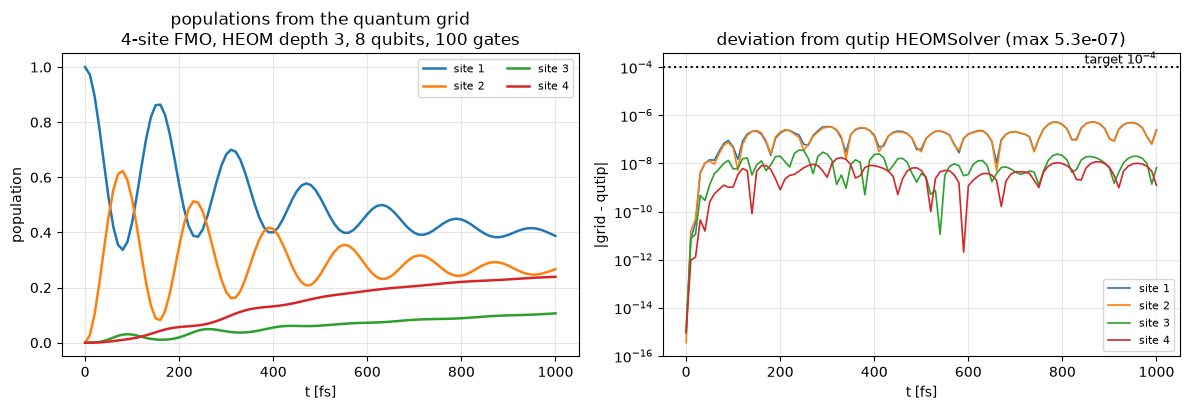

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i in range(N):
    ax[0].plot(idx * dt_fs, pops_tr[:, i], color=cols[i], lw=1.8,
               label=f'site {i+1}')
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('population')
ax[0].set_title(f'populations from the quantum grid\n{N}-site FMO, HEOM depth '
                f'{HEOM_depth}, {grid["n_qubits"]} qubits, {N_STEPS} gates')
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)

for i in range(N):
    ax[1].semilogy(idx * dt_fs, np.abs(pops_tr[:, i] - pops_qutip[idx, i]) + 1e-18,
                   color=cols[i], lw=1.2, label=f'site {i+1}')
ax[1].axhline(1e-4, color='k', ls=':', lw=1.5)
ax[1].text(t_fs[-1], 1.35e-4, r'target $10^{-4}$', ha='right', fontsize=9)
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel('|grid - qutip|')
ax[1].set_title(f'deviation from qutip HEOMSolver (max {err_grid:.1e})')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/grid_vs_qutip_N{N}.png', dpi=160)
plt.show()

## 9b  Off-diagonal elements: the coherences

The populations were never the whole story --- $\operatorname{vec}\rho_S = R\,y_t$
delivers all $d^2$ entries, and the diagonal was simply the only part being read
out.  `run_grid` now returns the full density matrix in `info`:

| key | content |
| :--- | :--- |
| `info['rho_tr']` | $(n_t,d,d)$, trace-normalised --- $p_t$ cancels, so this is **exact** |
| `info['rho']` | the same via eq. (5.1), i.e. scaled by $\lambda_t\propto\sqrt{p_t}$ |
| `info['rho_err']` | $1\sigma$ shot error of the eq. (5.1) route |

**Watch which one you plot.**  These are the same two readouts as in section 9,
now for every matrix element: `rho_tr` reproduces qutip at the level of the
solver's own tolerance ($\sim\!5\times10^{-7}$), while `rho` inherits the
$1/\sqrt{N}$ noise of $p_t$ ($\sim\!10^{-2}$ at a few thousand shots).  The
panels on the right show both, so the gap is visible rather than surprising.

The coherences cost nothing extra, and their error is the *same relative factor*
as for the populations: everything scales with the single number $\lambda_t$.

In [ ]:
from heom_gauge import qutip_reference_rho

rho_ref = qutip_reference_rho(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
jr    = info['t_index']
rho_n = info['rho_tr']          # spur-normiert: p_t kuerzt sich heraus -> exakt
rho_p = info['rho']             # ueber eq. (5.1), also mit sqrt(p_t) aus den Counts
rerr  = info['rho_err']         # Fehlerbalken der (5.1)-Route
okr   = np.isfinite(pops_grid[:, 0])

iu  = [(i, j) for i in range(N) for j in range(i + 1, N)]
sel = [iu[k] for k in np.argsort([np.abs(np.real(rho_ref[:, i, j])).max()
                                  for i, j in iu])[::-1][:4]]
dev = lambda a, i, j: np.abs(np.real(a[okr, i, j]) - np.real(rho_ref[jr[okr], i, j]))
print("ausgewaehlte Offdiagonalelemente:", [f"rho_{i+1}{j+1}" for i, j in sel])
print(f"  Diagonale    : Tr-Ablesung {max(dev(rho_n,i,i) for i in range(N)).max():.3e}"
      f"   |  (5.1)-Ablesung {max(dev(rho_p,i,i) for i in range(N)).max():.3e}")
print(f"  Kohaerenzen  : Tr-Ablesung {max(dev(rho_n,i,j) for i,j in sel).max():.3e}"
      f"   |  (5.1)-Ablesung {max(dev(rho_p,i,j) for i,j in sel).max():.3e}")

fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))

for i in range(N):                                   # oben links: Diagonale
    ax[0, 0].plot(t_fs, np.real(rho_ref[:, i, i]), color=cols[i], lw=1.4, alpha=.55)
    ax[0, 0].plot(jr[okr] * dt_fs, np.real(rho_n[okr, i, i]), 'o', ms=4,
                  color=cols[i], label=f'site {i+1}')
ax[0, 0].set_ylabel('population')
ax[0, 0].set_title('diagonal: populations (line = qutip, dots = grid)')
ax[0, 0].legend(fontsize=7, ncol=2); ax[0, 0].grid(alpha=.3)

for i in range(N):                                   # oben rechts: beide Fehler
    ax[0, 1].semilogy(jr[okr] * dt_fs, dev(rho_n, i, i) + 1e-18, 'o-', ms=3,
                      color=cols[i], label=f'site {i+1}')
    ax[0, 1].semilogy(jr[okr] * dt_fs, dev(rho_p, i, i) + 1e-18, ':', lw=1,
                      color=cols[i], alpha=.7)
ax[0, 1].plot([], [], 'k-', label='Tr-Ablesung (exakt)')
ax[0, 1].plot([], [], 'k:', label=r'(5.1) ueber $\sqrt{p_t}$')
ax[0, 1].set_title('deviation of the diagonal from qutip')
ax[0, 1].legend(fontsize=7, ncol=2); ax[0, 1].grid(alpha=.3, which='both')

for n, (i, j) in enumerate(sel):                     # unten links: Offdiagonale
    ax[1, 0].plot(t_fs, np.real(rho_ref[:, i, j]), color=cols[n], lw=1.4, alpha=.55)
    ax[1, 0].plot(jr[okr] * dt_fs, np.real(rho_n[okr, i, j]), 's', ms=4,
                  color=cols[n], label=rf'Re $\rho_{{{i+1}{j+1}}}$')
ax[1, 0].set_xlabel('t [fs]'); ax[1, 0].set_ylabel('coherence')
ax[1, 0].set_title('off-diagonal: coherences (line = qutip, squares = grid)')
ax[1, 0].legend(fontsize=7, ncol=2); ax[1, 0].grid(alpha=.3)

for n, (i, j) in enumerate(sel):                     # unten rechts: beide Fehler
    ax[1, 1].semilogy(jr[okr] * dt_fs, dev(rho_n, i, j) + 1e-18, 's-', ms=3,
                      color=cols[n], label=rf'$\rho_{{{i+1}{j+1}}}$')
    ax[1, 1].semilogy(jr[okr] * dt_fs, dev(rho_p, i, j) + 1e-18, ':', lw=1,
                      color=cols[n], alpha=.7)
ax[1, 1].set_xlabel('t [fs]')
ax[1, 1].set_title('deviation of the off-diagonal from qutip')
ax[1, 1].legend(fontsize=7, ncol=2); ax[1, 1].grid(alpha=.3, which='both')

fig.tight_layout(); fig.savefig(f'{PIC}/offdiag_N{N}.png', dpi=160)
plt.show()

In [8]:
SHOTS_S, EVERY_S = 1024, 1

t0 = time.time()
pops_s, err_s, info_s = run_grid_shots(grid, N_STEPS, shots=SHOTS_S,
                                       save_every=EVERY_S)
print(f"  simulation: {time.time() - t0:.1f} s")
js = info_s['t_index']
ok_s = np.isfinite(pops_s[:, 0])
print(f"\n  shot-based vs qutip : {np.abs(pops_s[ok_s] - pops_qutip[js[ok_s]]).max():.3e}")
print(f"  typical error bar   : {np.nanmean(err_s[ok_s]):.3e}")
print(f"  accepted shots      : {info_s['accepted'][ok_s]}")

# Theoretische Referenzkurve für die Post-Selection-Wahrscheinlichkeit
p_gau_ref = post_selection_curve(grid['Pt'], grid['Wh'] @ x0, N_STEPS, grid['s'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# --- Panel 0: Populationen (Shot-basiert vs. QuTiP-Referenz) ---
for i in range(N):
    # Kontinuierliche QuTiP-Referenzlinie
    ax[0].plot(t_fs, pops_qutip[:, i], color=cols[i], lw=1.5, alpha=0.7,
               linestyle='-', label=f'site {i+1} (QuTiP)' if i == 0 else None)
    # Shot-basierte Messwerte mit Fehlerbalken
    ax[0].errorbar(js[ok_s] * dt_fs, pops_s[ok_s, i], yerr=err_s[ok_s, i],
                   fmt='o', ms=4, capsize=3, color=cols[i],
                   label=f'site {i+1} (grid)')

ax[0].set_xlabel('t [fs]')
ax[0].set_ylabel('population')
ax[0].set_title(f'shot-based read-out vs. QuTiP reference ({SHOTS_S} shots)')
ax[0].legend(fontsize=8, ncol=2)
ax[0].grid(alpha=.3)

# --- Panel 1: Post-Selection-Wahrscheinlichkeit ---
# Exakte Kontraktions-Kurve als Referenz
ax[1].plot(t_fs, p_gau_ref, color='black', ls='--', lw=1.5,
           alpha=0.8, label='exact $p_{\\rm total}(t)$')
# Gemessene Werte aus den Counts
ax[1].errorbar(js[ok_s] * dt_fs, info_s['p_success'][ok_s],
               yerr=info_s['p_success_err'][ok_s], fmt='s', color='C4',
               ms=4, capsize=3, label='measured $p_{\\rm total}$')

ax[1].set_xlabel('t [fs]')
ax[1].set_ylabel(r'$p_{\rm total}$')
ax[1].set_ylim(0, 1.05)
ax[1].set_title('post-selection probability from counts')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=.3)

fig.tight_layout()
fig.savefig(f'{PIC}/shots_N{N}.png', dpi=160)
plt.show()

KeyboardInterrupt: 

## 10  Why the gauge is the whole story

Equation (2.2) is a product of two factors, $1/s^{2n}$ and
$\lVert M^nx\rVert^2/\lVert x\rVert^2$.  In the Euclidean metric **both** are
astronomical and very nearly -- but not nearly enough -- cancel.  The left panel
shows why the second one blows up: almost all of the Euclidean norm of
$\vec\Sigma$ sits in the ADOs, which are bookkeeping objects for the bath
correlations, not density matrices, and nothing requires them to stay bounded.
The physical part is perfectly well behaved the whole time.

The gauge measures the same trajectory with a yardstick under which it is a
contraction, and then each factor separately is $O(1)$.

  ||Sigma_n||/||Sigma_0||: max 3165, final 1101
  of which the system block is 5.209e-04
  ||vec rho_S(T)|| = 0.573457   Tr rho_S(T) = 1.000000


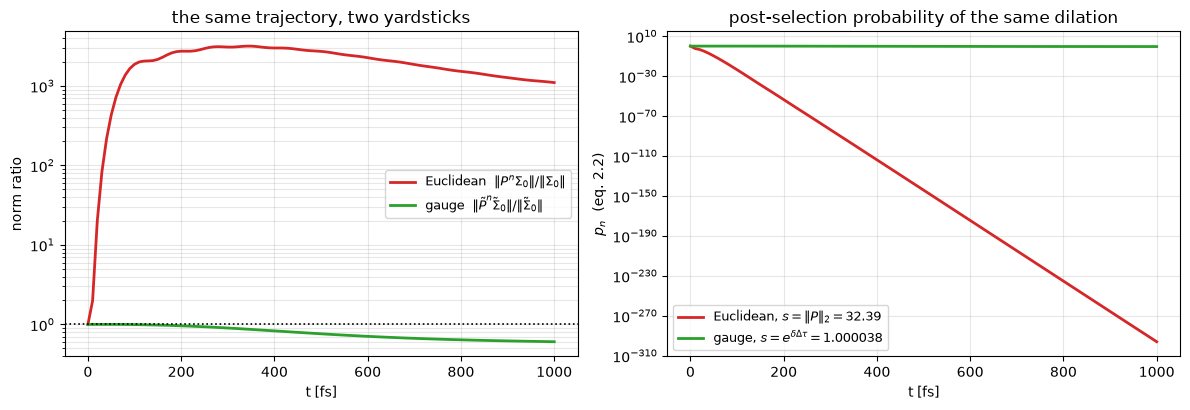


  Euclidean: p(100) = 9.899e-297   = 8.166e-303 (part 1) x 1.212e+06 (part 2)
  gauge    : p(100) = 3.646e-01   ratio 3.68e+295


In [ ]:
x0 = np.zeros(grid['A'].shape[0], complex)
x0[:grid['D']] = rho0.flatten(order='F')
xt0 = grid['Wh'] @ x0

s_raw = float(np.linalg.norm(P, 2))
p_raw = post_selection_curve(P,  x0,  N_STEPS, s_raw)
p_gau = post_selection_curve(Pt, xt0, N_STEPS, grid['s'])
n_raw = np.sqrt(post_selection_curve(P,  x0,  N_STEPS, 1.0))   # ||P^n x||/||x||
n_gau = np.sqrt(post_selection_curve(Pt, xt0, N_STEPS, 1.0))

# what fraction of the Euclidean norm is the physical state at the end?
x = x0.copy()
for _ in range(N_STEPS):
    x = P @ x
rho_end = x[:grid['D']].reshape(N, N, order='F')
print(f"  ||Sigma_n||/||Sigma_0||: max {n_raw.max():.4g}, final {n_raw[-1]:.4g}")
print(f"  of which the system block is {np.linalg.norm(x[:grid['D']])/np.linalg.norm(x):.3e}")
print(f"  ||vec rho_S(T)|| = {np.linalg.norm(x[:grid['D']]):.6f}   "
      f"Tr rho_S(T) = {np.real(np.trace(rho_end)):.6f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(t_fs, n_raw, lw=2, color='C3',
               label=r'Euclidean  $\|P^n\Sigma_0\|/\|\Sigma_0\|$')
ax[0].semilogy(t_fs, n_gau, lw=2, color='C2',
               label=r'gauge  $\|\tilde P^n\tilde\Sigma_0\|/\|\tilde\Sigma_0\|$')
ax[0].axhline(1, color='k', ls=':', lw=1.2)
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('norm ratio')
ax[0].set_title('the same trajectory, two yardsticks')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3, which='both')

ax[1].semilogy(t_fs, np.maximum(p_raw, 1e-320), lw=2, color='C3',
               label=rf'Euclidean, $s=\|P\|_2={s_raw:.2f}$')
ax[1].semilogy(t_fs, p_gau, lw=2, color='C2',
               label=rf'gauge, $s=e^{{\delta\Delta\tau}}={grid["s"]:.6f}$')
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel(r'$p_n$  (eq. 2.2)')
ax[1].set_title('post-selection probability of the same dilation')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/gauge_postselection_N{N}.png', dpi=160)
plt.show()

print(f"\n  Euclidean: p({N_STEPS}) = {p_raw[-1]:.3e}   "
      f"= {1/s_raw**(2*N_STEPS):.3e} (part 1) x {n_raw[-1]**2:.3e} (part 2)")
print(f"  gauge    : p({N_STEPS}) = {p_gau[-1]:.3e}   "
      f"ratio {p_gau[-1] / max(p_raw[-1], 1e-320):.2e}")

## 11  Convergence in the Krylov dimension $m$

Proposition 6 guarantees $\lVert H_m\rVert\le\lVert\tilde P\rVert$ for every $m$,
so raising $m$ costs nothing except $\lceil\log_2m\rceil$ qubits.  `regrid`
reuses the gauge, so a scan over $m$ costs only $m$ matrix-vector products per
point.

The floor at $\approx5\times10^{-7}$ is the qutip solver's own integration
tolerance, not ours: iterating the full $2640\times2640$ propagator $P$ directly,
with no compression and no gauge, reproduces exactly the same number.

In [ ]:
scan = {}
for m_try in (16, 32, 64, 96, 128):
    g = regrid(grid, m_try)
    pk = reference_trajectory(g, N_STEPS)
    scan[g['m']] = (g['n_qubits'], float(np.linalg.norm(g['Hm'], 2)),
                    np.abs(pk - pops_qutip).max(),
                    post_selection_curve(g['Hm'], g['y0'], N_STEPS, g['s'])[-1])
    print(f"  m={g['m']:4d}  qubits={scan[g['m']][0]:2d}  "
          f"||H_m||={scan[g['m']][1]:.6f}  vs qutip={scan[g['m']][2]:.3e}  "
          f"p({N_STEPS})={scan[g['m']][3]:.3e}")

x, pfull = x0.copy(), []
for _ in range(N_STEPS + 1):
    pfull.append(np.real(np.diag(x[:grid['D']].reshape(N, N, order='F'))))
    x = P @ x
print(f"\n  full P, no Krylov and no gauge    vs qutip = "
      f"{np.abs(np.array(pfull) - pops_qutip).max():.3e}   <- solver tolerance")

  m=  16  qubits= 5  ||H_m||=1.000038  vs qutip=1.926e-01  p(100)=1.723e-01
  m=  32  qubits= 6  ||H_m||=1.000038  vs qutip=6.217e-02  p(100)=3.321e-01
  m=  64  qubits= 7  ||H_m||=1.000038  vs qutip=5.267e-07  p(100)=3.646e-01
  m=  96  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01
  m= 128  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01

  full P, no Krylov and no gauge    vs qutip = 5.268e-07   <- solver tolerance


## 12  Robustness across the parameter range, and where it breaks

The gauge guarantees $\lVert\tilde P\rVert_2\le e^{\delta\Delta\tau}$ (Theorem 4),
so comparing the measured norm against that bound is a **free validity check**:
if it is exceeded, the arithmetic has failed, not the theory.  Forming $W$ and
then taking $W^{\pm1/2}$ squares the condition number, so a generator with a
large transient can push $\mathrm{cond}(W)$ past what float64 carries.
`build_grid` raises a `RuntimeWarning` when that happens -- the second case
below deliberately triggers it.

In [ ]:
import warnings

cases = [('reference      ', LAM_FMO, GAM_FMO, T_FMO),
         ('strong coupling',   35.0,   106.14,  300.0),
         ('very strong    ',  100.0,     50.0,  300.0)]
print(f"{'case':16s} {'scaled':>7s} {'||P||':>11s} {'||P~||':>10s} {'bound':>9s} "
      f"{'cond(W)':>9s} {'vs qutip':>10s} {'p(100)':>11s}  ok?")
for name, lam, gam, T_K in cases:
    M2 = dict(MODEL); M2.update(lam=lam, gamma=gam, T_K=T_K)
    ref2 = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **M2)
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            g2 = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                            depth=HEOM_depth, verbose=False,
                            scale_ados=True, **M2)
        pk2 = reference_trajectory(g2, N_STEPS)
        p2_ = post_selection_curve(g2['Hm'], g2['y0'], N_STEPS, g2['s'])[-1]
        gi  = g2['gauge']
        print(f"{name:16s} {str(True):>7s} {gi['norm_P']:11.4g} {gi['norm_Pt']:10.4f} "
                f"{gi['bound']:9.6f} {gi['cond']:9.2e} {np.abs(pk2-ref2).max():10.3e} "
                f"{p2_:11.3e}  {'yes' if gi['trustworthy'] else 'NO'}")
    except Exception as e:
        print(f"{name:16s} {str(True):>7s}  FAILED: {type(e).__name__}: {str(e)[:55]}")

print("   Ohne Skalierung traegt P das volle transiente Wachstum, cond(W) ~ ||P||^2")
print("   reisst die float64-Grenze, und W^(-1/2) wird aus Rauschen gebaut.")

case                      ||P||     ||P~||     bound   cond(W)   vs qutip     p(100)  ok?
10.0%. Run time:   0.03s. Est. time left: 00:00:00:00
20.0%. Run time:   0.05s. Est. time left: 00:00:00:00
30.0%. Run time:   0.07s. Est. time left: 00:00:00:00
40.0%. Run time:   0.09s. Est. time left: 00:00:00:00
50.0%. Run time:   0.12s. Est. time left: 00:00:00:00
60.0%. Run time:   0.14s. Est. time left: 00:00:00:00
70.0%. Run time:   0.17s. Est. time left: 00:00:00:00
80.0%. Run time:   0.19s. Est. time left: 00:00:00:00
90.0%. Run time:   0.21s. Est. time left: 00:00:00:00
100.0%. Run time:   0.23s. Est. time left: 00:00:00:00
Total run time:   0.23s
reference                 32.39     1.0000  1.000038  1.74e+10  5.268e-07  3.646e-01  yes
10.0%. Run time:   0.07s. Est. time left: 00:00:00:00
20.0%. Run time:   0.09s. Est. time left: 00:00:00:00
30.0%. Run time:   0.12s. Est. time left: 00:00:00:00
40.0%. Run time:   0.14s. Est. time left: 00:00:00:00
50.0%. Run time:   0.16s. Est. time lef

## 13  Comparison with the transfer-tensor / companion route

Same model, same benchmark.  The middle column counts the time steps that have
to be produced on the classical computer before the grid can start.

In [ ]:
comp = {}
for K in (10, 25, 40):
    pc, E = companion_baseline(P, K, N, rho0, N_STEPS)
    comp[K] = (np.abs(pc - pops_qutip).max(), pc, float(np.linalg.norm(E, 2)))
    print(f"  companion K={K:3d}: {K:3d} classical steps "
          f"({100*K/N_STEPS:3.0f} % of the run), vs qutip = {comp[K][0]:.3e}, "
          f"||E||_2 = {comp[K][2]:.3f}")
print(f"\n  this folder      :   0 classical steps (  0 % of the run), "
      f"vs qutip = {err_grid:.3e}")

  companion K= 10:  10 classical steps ( 10 % of the run), vs qutip = 5.657e-02, ||E||_2 = 1.414
  companion K= 25:  25 classical steps ( 25 % of the run), vs qutip = 5.580e-03, ||E||_2 = 1.414
  companion K= 40:  40 classical steps ( 40 % of the run), vs qutip = 9.029e-04, ||E||_2 = 1.414

  this folder      :   0 classical steps (  0 % of the run), vs qutip = 5.268e-07


In [ ]:
fig, ax = plt.subplots(figsize=(7.8, 4.5))
for K, c in zip((10, 25, 40), ('C3', 'C1', 'C0')):
    ax.semilogy(t_fs, np.abs(comp[K][1] - pops_qutip).max(axis=1) + 1e-18,
                color=c, lw=1.6, label=f'companion, K={K} ({K} classical steps)')
    ax.axvline(K * dt_fs, color=c, ls=':', lw=1, alpha=.6)
ax.semilogy(idx * dt_fs, np.abs(pops_tr - pops_qutip[idx]).max(axis=1) + 1e-18,
            color='C2', lw=2.2, label='quantum grid (0 classical steps)')
ax.axhline(1e-4, color='k', ls='--', lw=1.2)
ax.text(t_fs[-1], 1.35e-4, r'target $10^{-4}$', ha='right', fontsize=9)
ax.set_xlabel('t [fs]'); ax.set_ylabel('max deviation from qutip HEOMSolver')
ax.set_title('truncating the memory kernel vs. keeping the ADOs')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/vs_companion_N{N}.png', dpi=160)
plt.show()

## 14  Long runs

Proposition 6 makes $\lVert H_m\rVert\le e^{\delta\Delta\tau}$, so the iteration
cannot blow up: the grid is unconditionally stable however long it runs.  The
only drift is the deliberate factor $e^{-2\delta T}$ of (3.5), which is why
$\delta$ is kept small.

10.0%. Run time:   0.11s. Est. time left: 00:00:00:01


20.0%. Run time:   0.21s. Est. time left: 00:00:00:00


30.0%. Run time:   0.37s. Est. time left: 00:00:00:00


40.0%. Run time:   0.50s. Est. time left: 00:00:00:00


50.0%. Run time:   0.59s. Est. time left: 00:00:00:00


...

100.0%. Run time:   1.09s. Est. time left: 00:00:00:00


Total run time:   1.09s


  grid: 8 qubits, 500 applications of one gate, circuit depth 1500, 512 shots


  post-selection probability: 1.0000 -> 0.2441


  simulation: 97.7 s
  500 steps = 5 ps on one grid
  QUANTUM GRID vs qutip HEOMSolver : 1.853e-06
  norm from the record (eq. 5.1)   : 1.193e-02
  post-selection probability       : 1.0000 -> 0.2441   (plateaus once the state has relaxed)


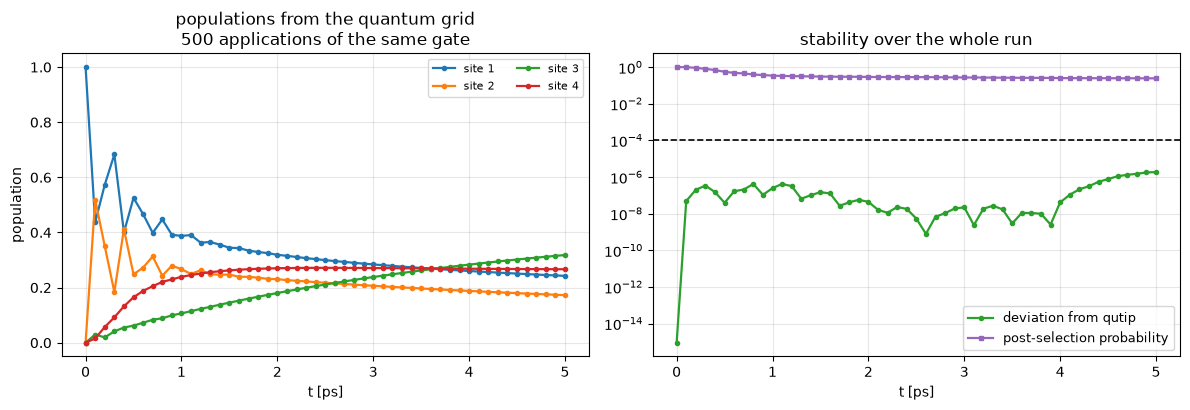

In [ ]:
N_LONG, SAVE_EVERY = 500, 10        # 5 ps
t_long = np.arange(N_LONG + 1) * dt_fs
ref_long = qutip_reference(t_long, rho0=rho0, depth=HEOM_depth, **MODEL)

t0 = time.time()
pl, pl_tr, il = run_grid(grid, N_LONG, shots=SHOTS, save_every=SAVE_EVERY)
print(f"  simulation: {time.time() - t0:.1f} s")
jl = il['t_index']
print(f"  {N_LONG} steps = {t_long[-1]/1000:.0f} ps on one grid")
print(f"  QUANTUM GRID vs qutip HEOMSolver : {np.abs(pl_tr - ref_long[jl]).max():.3e}")
print(f"  norm from the record (eq. 5.1)   : {np.abs(pl - ref_long[jl]).max():.3e}")
print(f"  post-selection probability       : {il['p_success'][0]:.4f} -> "
      f"{il['p_success'][-1]:.4f}   (plateaus once the state has relaxed)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i in range(N):
    ax[0].plot(jl * dt_fs / 1000, pl_tr[:, i], 'o-', color=cols[i], lw=1.6, ms=3,
               label=f'site {i+1}')
ax[0].set_xlabel('t [ps]'); ax[0].set_ylabel('population')
ax[0].set_title(f'populations from the quantum grid\n'
                f'{N_LONG} applications of the same gate')
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)
ax[1].semilogy(jl * dt_fs / 1000, np.abs(pl_tr - ref_long[jl]).max(axis=1) + 1e-18,
               'o-', color='C2', lw=1.6, ms=3, label='deviation from qutip')
ax[1].semilogy(jl * dt_fs / 1000, il['p_success'], 's-', color='C4', lw=1.6, ms=3,
               label='post-selection probability')
ax[1].axhline(1e-4, color='k', ls='--', lw=1.2)
ax[1].set_xlabel('t [ps]'); ax[1].set_title('stability over the whole run')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/long_run_N{N}.png', dpi=160)
plt.show()

## 15  The circuit

Three repetitions of the single unit; the full run is the same picture
`N_STEPS` times.  `U` is the dilation (2.1) of the padded $H_m$.

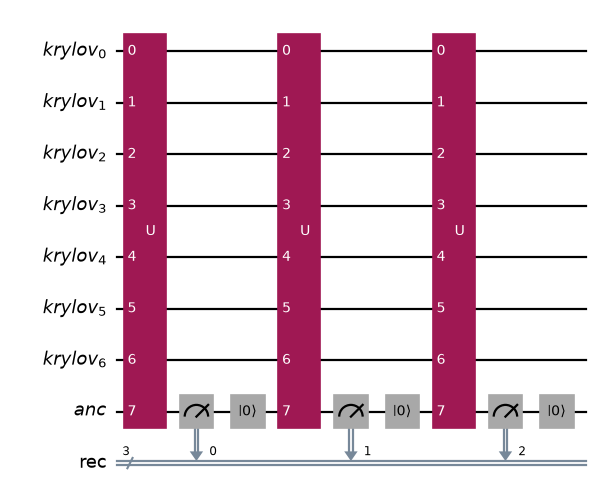

  8 qubits, 100 applications of one gate, depth 300, 300 instructions


In [ ]:
qc3 = build_circuit(grid, 3, save_states=False)
fig = qc3.draw('mpl', fold=-1, scale=.8)
fig.savefig(f'{PIC}/circuit_N{N}.png', dpi=160, bbox_inches='tight')
display(fig)

qc_full = build_circuit(grid, N_STEPS, save_states=False)
print(f"  {grid['n_qubits']} qubits, {N_STEPS} applications of one gate, "
      f"depth {qc_full.depth()}, {len(qc_full.data)} instructions")

## 16  One state in, one state out

The minimal statement of the task: the circuit is read only at the end -- the
version that would run on hardware, where `save_statevector` does not exist and
the accepted shots are all one gets.

Here the two readouts part company.  By Proposition 7 the accepted *state* is
exact, so the trace-normalised readout is already exact from a single accepted
shot; the normalisation it uses, $\operatorname{Tr}\rho_S(t)=1$, is a property
of the dynamics and not extra information about the answer.  The readout through
(5.1) instead estimates $\lVert y_t\rVert$ from the acceptance rate and
therefore carries the usual $1/\sqrt{N_{\rm acc}}$ shot noise.

In [ ]:
print(f'  read only at t = {N_STEPS*dt_fs:.0f} fs:')
for sh in (256, 1024, 4096):
    pf, pf_tr, isf = run_grid_final(grid, N_STEPS, shots=sh, verbose=False)
    n_ok = int(round(isf['p_success'][-1] * sh))
    print(f"    shots={sh:6d} ({n_ok:6d} accepted, p={isf['p_success'][-1]:.4f})   "
          f"eq.(5.1) readout {np.abs(pf - pops_qutip[N_STEPS]).max():.3e}   "
          f"trace readout {np.abs(pf_tr - pops_qutip[N_STEPS]).max():.3e}")

  read only at t = 1000 fs:


    shots=   256 (   114 accepted, p=0.4453)   eq.(5.1) readout 4.076e-02   trace readout 2.486e-07


    shots=  1024 (   386 accepted, p=0.3770)   eq.(5.1) readout 6.507e-03   trace readout 2.486e-07


    shots=  4096 (  1500 accepted, p=0.3662)   eq.(5.1) readout 8.500e-04   trace readout 2.486e-07


## 17  Summary

| | classical time steps | qubits | deviation from qutip `HEOMSolver` |
|---|---|---|---|
| companion, $K=10$ | 10 | 9 | $5.7\times10^{-2}$ |
| companion, $K=25$ | 25 | 10 | $5.6\times10^{-3}$ |
| companion, $K=40$ | 40 | 11 | $9.0\times10^{-4}$ |
| **this folder, $m=64$** | **0** | **7** | $5.3\times10^{-7}$ |
| **this folder, $m=128$** | **0** | **8** | $5.3\times10^{-7}$ |

The companion qubit counts are for the uncompressed register,
$\lceil\log_2Kd^2\rceil+1$.  Krylov compression shrinks them too, but it cannot
repair the truncation error, and applied to the raw $E$ it is unstable for the
reason given in section 2.

$5.3\times10^{-7}$ is the qutip solver's own integration tolerance -- iterating
the full $2640\times2640$ propagator reproduces the same figure, and the Krylov
truncation error measured against *that* exact trajectory is
$1.9\times10^{-14}$ over 100 steps and $1.7\times10^{-8}$ over 500 steps at
$m=128$.

What made the difference was not a better memory kernel but dropping the memory
kernel altogether: the ADOs already carry the full history, so equation (1.1) is
exact and $K$ disappears.  The single obstruction was that the exact propagator
has $\lVert P\rVert_2=32$ while $\rho(P)=1$ -- and by Theorem 4 that is a
property of the inner product, not of the physics.  Proposition 6 then makes the
compression free, and Proposition 7 makes the post-selected branch exact.